Optimal number of PCA components: 2


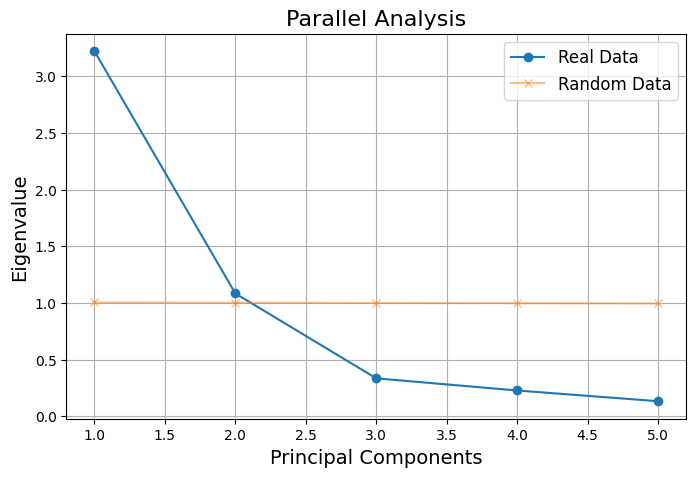

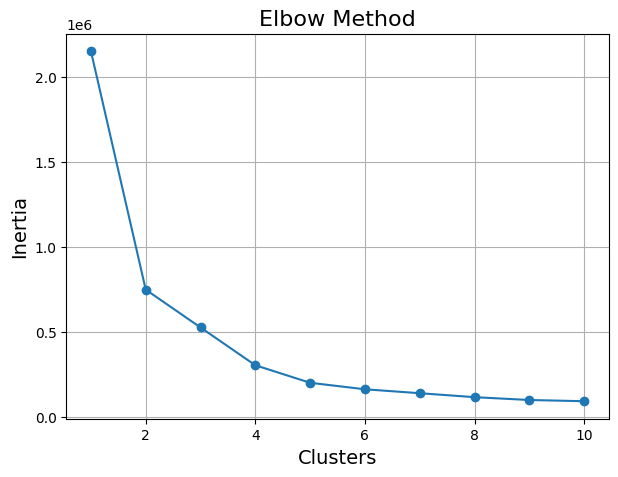

Renumeración: {1: 0, 2: 1, 0: 2, 3: 3}


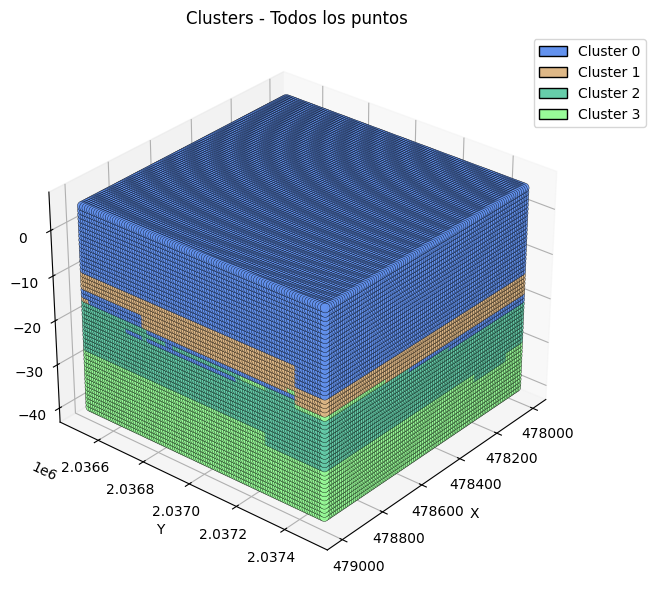

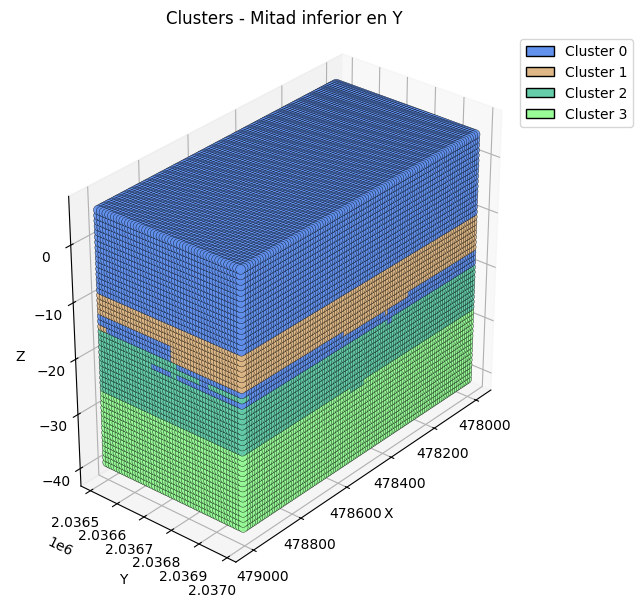

In [6]:
# === Importar librerías ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D


def plot_clusters(df, title="Clusters 3D", aspect=None):

    fig = plt.figure(figsize=(20,6))
    ax = fig.add_subplot(111, projection="3d")

    colors = df["CLUSTER"].map(colores)

    ax.scatter(
        df["X"],
        df["Y"],
        df["Z"],
        c=colors,
        s=50,
        edgecolor="black",
        linewidth=0.3,
        alpha=0.9
    )

    legend_elements = [
        Patch(facecolor=colores[i],
              edgecolor="black",
              label=f"Cluster {i}")
        for i in sorted(colores.keys())
    ]

    ax.legend(handles=legend_elements,
              loc="upper right",
              bbox_to_anchor=(1.15,1))

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.view_init(elev=30, azim=40)

    if aspect:
        ax.set_box_aspect(aspect)

    plt.tight_layout()
    plt.show()

# === Cargar datos ===
df = pd.read_csv('/content/Variables.csv').dropna().reset_index(drop=True)

# === Seleccionar columnas de interés ===
columnas_features = ['fs', 'qc', 'u2', 'N', 'Vs']
data = df[columnas_features]
coords = df[['X', 'Y', 'Z']]

# === Normalizar los datos ===
X_scaled = StandardScaler().fit_transform(data)

# === Parallel Analysis ===
np.random.seed(42)  # reproducibilidad de las simulaciones aleatorias

n_simulations = 500  # reducimos un poco para velocidad
pca_real = PCA().fit(X_scaled)
real_eigenvalues = pca_real.explained_variance_

random_eigenvalues = np.array([
    PCA().fit(np.random.normal(0, 1, size=X_scaled.shape)).explained_variance_
    for _ in range(n_simulations)
])
mean_random_eigenvalues = random_eigenvalues.mean(axis=0)

optimal_n_components = np.sum(real_eigenvalues > mean_random_eigenvalues)
print(f"Optimal number of PCA components: {optimal_n_components}")

# Graficar Parallel Analysis
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(real_eigenvalues) + 1), real_eigenvalues, label='Real Data', marker='o')
plt.plot(range(1, len(mean_random_eigenvalues) + 1), mean_random_eigenvalues,
         label='Random Data', marker='x', alpha=0.5)
plt.xlabel('Principal Components', fontsize=14)
plt.ylabel('Eigenvalue', fontsize=14)
plt.title('Parallel Analysis', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# === Aplicar PCA ===
pca = PCA(int(optimal_n_components))
principalComponents = pca.fit_transform(X_scaled)

# === Clusterización KMeans ===
inercias = [KMeans(n_clusters=k, random_state=42).fit(principalComponents).inertia_
            for k in range(1, 11)]

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inercias, marker='o')
plt.xlabel('Clusters', fontsize=14)
plt.ylabel('Inertia', fontsize=14)
plt.title('Elbow Method', fontsize=16)
plt.grid(True)
plt.show()

# ===================================================
# Aplicar KMeans final
# ===================================================

n_clusters = 4

clusters = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=20
).fit_predict(principalComponents)

# ===================================================
# Crear DataFrame
# ===================================================

df_clusters = coords.copy()
df_clusters[columnas_features] = data.values
df_clusters["CLUSTER"] = clusters

# ===================================================
# Reordenar clusters según profundidad media (Z)
# Cluster 0 = más superficial
# ===================================================

orden = (
    df_clusters
    .groupby("CLUSTER")["Z"]
    .mean()
    .sort_values(ascending=False)
)

nuevo_id = {
    viejo: nuevo
    for nuevo, viejo in enumerate(orden.index)
}

print("Renumeración:", nuevo_id)

df_clusters["CLUSTER"] = (
    df_clusters["CLUSTER"]
    .map(nuevo_id)
    .astype(int)
)

# ===================================================
# Colores (usar los mismos en todos los gráficos)
# ===================================================

colores = {
    0: "#6392EE",   # Azul
    1: "#DEB887",   # Beige
    2: "#66CDAA",   # Verde
    3: "#98FB98"    # Verde claro
}

# Guardar archivo
df_clusters.to_csv("PAII_CLUSTER.csv", index=False)

# ===================================================
# Visualización 3D
# ===================================================

plot_clusters(df_clusters, "Clusters - Todos los puntos")

# Mitad inferior

y_median = df_clusters["Y"].median()
df_mitad = df_clusters[df_clusters["Y"] <= y_median]

plot_clusters(
    df_mitad,
    "Clusters - Mitad inferior en Y",
    aspect=[1, 0.5, 0.8]
)

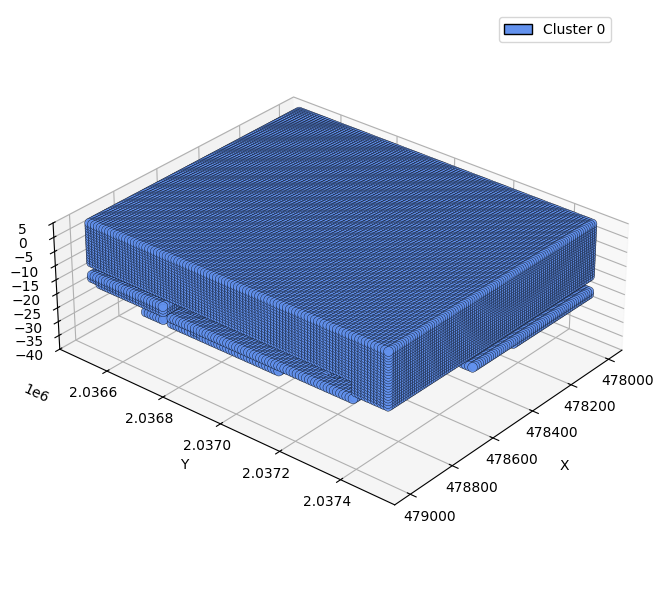

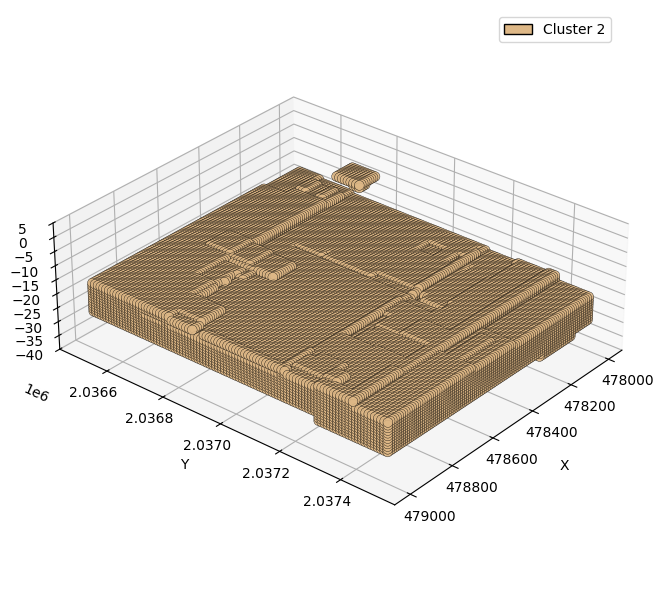

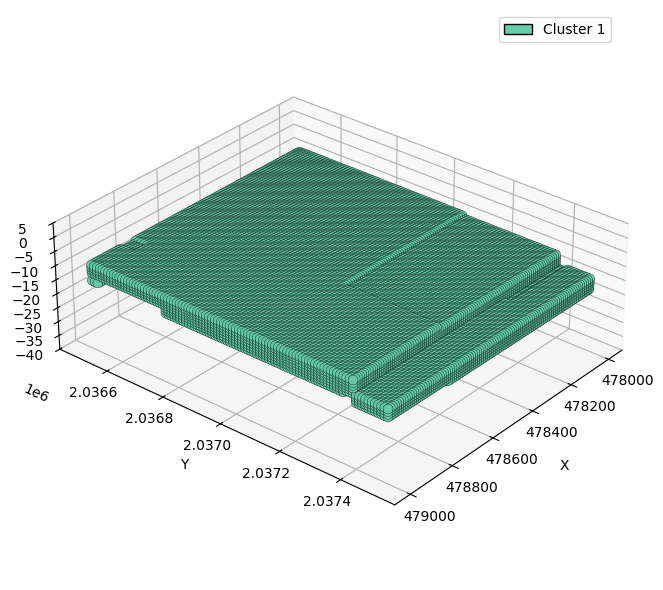

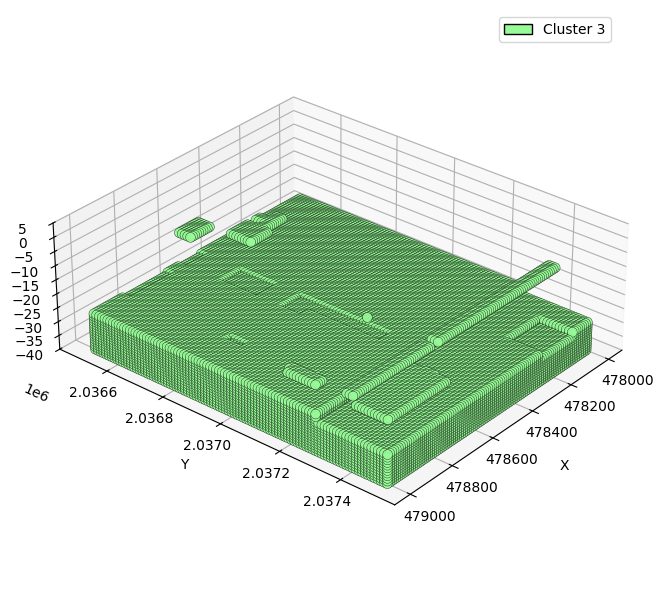

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Lista de clusters y colores
clusters = [0, 2, 1, 3]
colors = ['#6392EE', '#DEB887', '#66CDAA', '#98FB98']

# Límites globales del eje Z
zmin = df_clusters['Z'].min()
zmax = df_clusters['Z'].max()

for cluster_id, cluster_color in zip(clusters, colors):
    df_cluster = df_clusters[df_clusters['CLUSTER'] == cluster_id]

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        df_cluster['X'], df_cluster['Y'], df_cluster['Z'],
        c=cluster_color,
        s=50,
        edgecolor='black',
        linewidth=0.3,
        alpha=0.9
    )

    legend_element = [
        Patch(facecolor=cluster_color, edgecolor='black',
              label=f'Cluster {cluster_id}')
    ]
    ax.legend(handles=legend_element, loc='upper right')

    ax.set_xlabel('X', labelpad=10)
    ax.set_ylabel('Y', labelpad=10)
    ax.set_zlabel('Z', labelpad=10)

    # Mismo rango Z para todas las figuras
    ax.set_zlim(zmin, zmax)

    ax.view_init(elev=30, azim=40)
    ax.set_box_aspect([2.5, 3, 1])

    plt.tight_layout()
    plt.show()


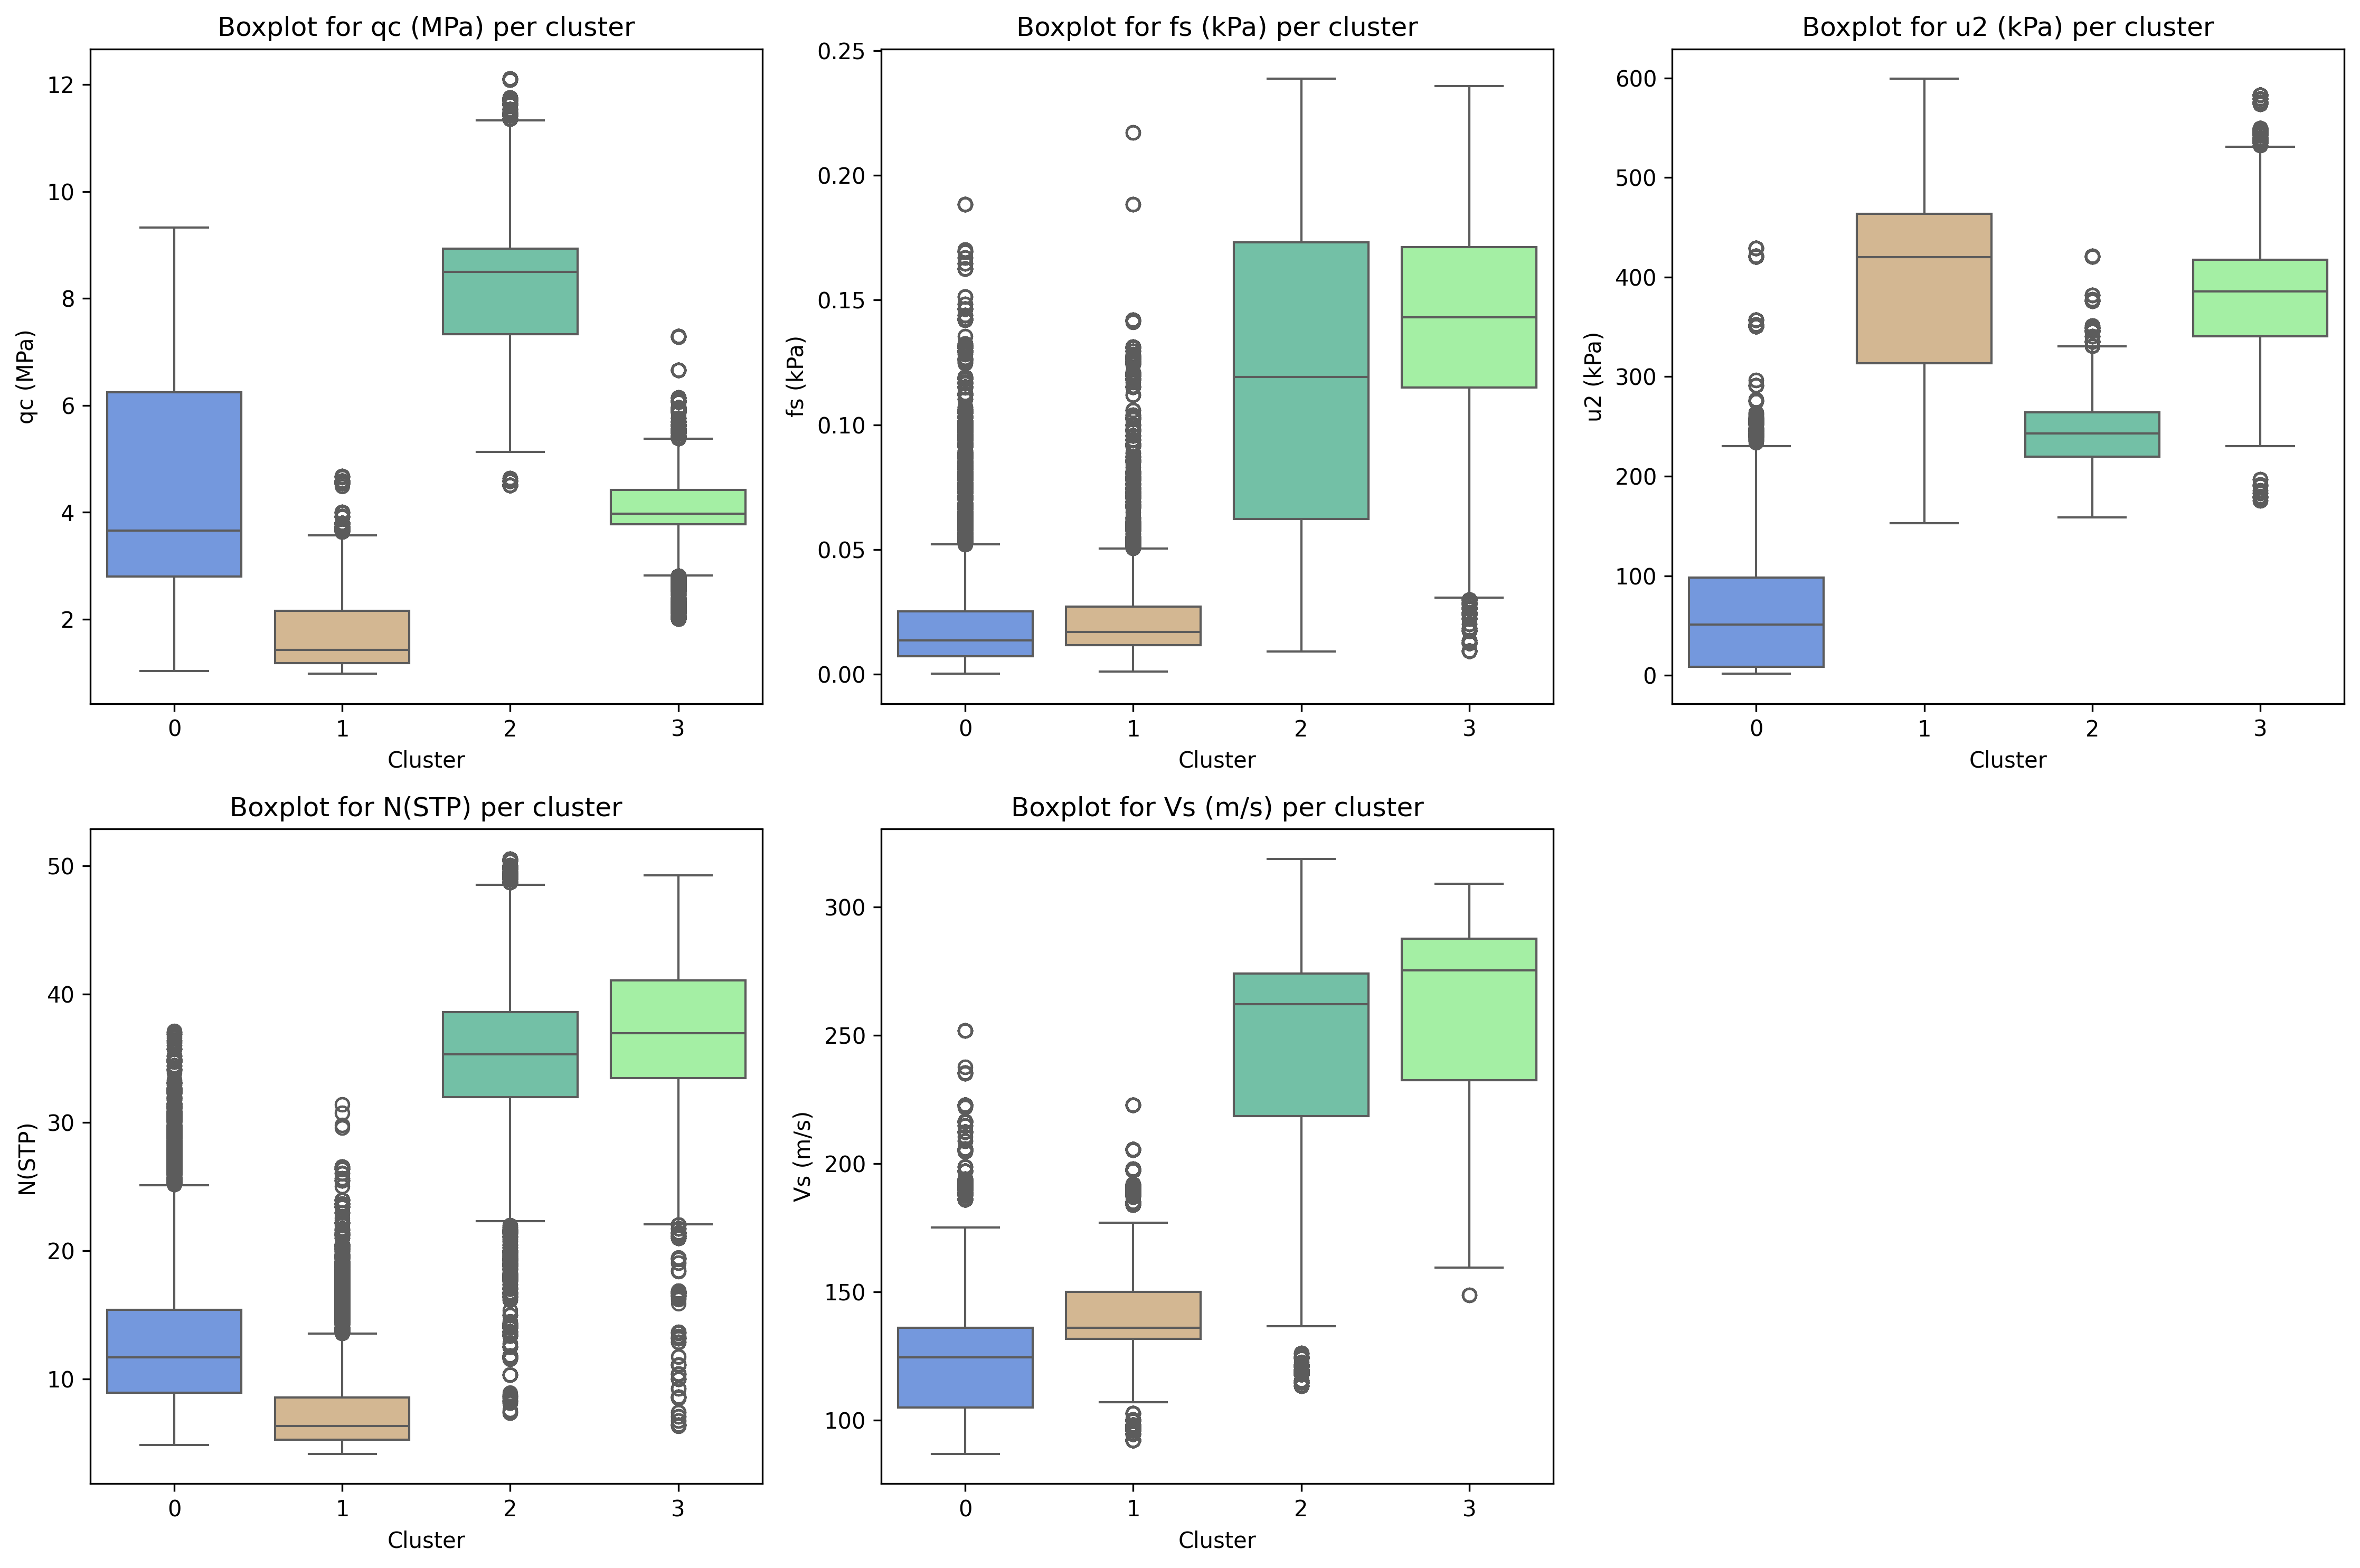

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

parametros = ['qc', 'fs', 'u2', 'N', 'Vs']

df_clusters = df_clusters.dropna(subset=['CLUSTER'] + parametros)
df_clusters["CLUSTER"] = df_clusters["CLUSTER"].astype(int)

fig, axs = plt.subplots(2, 3, figsize=(15,10), dpi=300)

graficos = [
    ('qc', 'Boxplot for qc (MPa) per cluster', 'qc (MPa)'),
    ('fs', 'Boxplot for fs (kPa) per cluster', 'fs (kPa)'),
    ('u2', 'Boxplot for u2 (kPa) per cluster', 'u2 (kPa)'),
    ('N',  'Boxplot for N(STP) per cluster', 'N(STP)'),
    ('Vs', 'Boxplot for Vs (m/s) per cluster', 'Vs (m/s)')
]

for ax, (col, titulo, ylabel) in zip(axs.flatten(), graficos):

    sns.boxplot(
        x="CLUSTER",
        y=col,
        data=df_clusters,
        hue="CLUSTER",
        palette=colores,
        legend=False,
        ax=ax
    )

    ax.set_title(titulo)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(ylabel)

# El sexto subplot queda vacío
axs[1,2].axis("off")

plt.tight_layout()
plt.show()

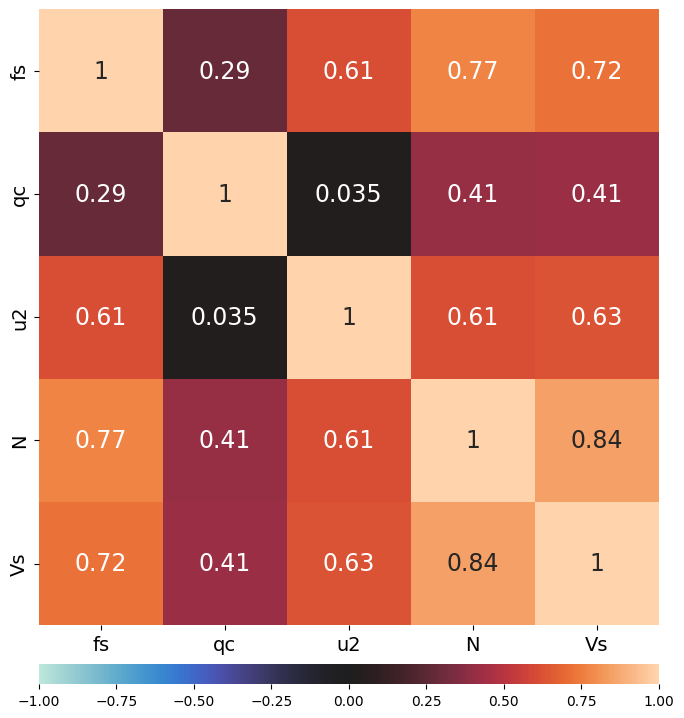

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# === Seleccionar columnas de interés ===
columnas_features = ['fs', 'qc', 'u2', 'N', 'Vs']
data = df[columnas_features]

# === Normalizar los datos ===
X_scaled = StandardScaler().fit_transform(data)

# Convertir a DataFrame con mismas columnas para poder usar .corr()
scaled_df = pd.DataFrame(X_scaled, columns=columnas_features)

# Calcular la matriz de correlación
corr = scaled_df.corr()

# === Graficar Heatmap ===
fig, ax = plt.subplots(figsize=(8, 10))

heatmap = sns.heatmap(
    corr, vmin=-1, vmax=1, center=0, annot=True, ax=ax,
    annot_kws={"size": 17},
    cbar_kws={"orientation": "horizontal", "pad": .05, "aspect": 30}
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
